# Ablation Study

In [52]:
from pathlib import Path
import pickle
import json

import pandas as pd
import numpy as np

from temp import (
    temp_metrics,
    plot_temp_consistency
)

In [53]:
dataset = "aitv2"
scenario = "santos"
test_scenario = "santos"
logic_file = "ait_logic"

attack_start = pd.Timestamp("2022-01-17 11:00")
attack_end   = pd.Timestamp("2022-01-17 12:00")

In [54]:
# Cross-scenario config
# scenario = "santos_fox"
# test_scenario = "fox"

# attack_start = pd.Timestamp("2022-01-18 11:59")
# attack_end   = pd.Timestamp("2022-01-18 13:15")

In [55]:
experiment = "ablation_study"
reports_dir = Path(f"../../reports/{dataset}/{experiment}")

plots_dir = reports_dir / "temp_plots"
plots_dir.mkdir(parents=True, exist_ok=True)

## Metrics

In [56]:
experiments = {}

### DPL

In [57]:
df = pd.read_csv(
    f"../../data/interim/{dataset}/{test_scenario}/flows_labeled/flows_augmented.csv"
)

df = df.sort_values("start_time").reset_index(drop=True)

In [58]:
df["start_time_dt"] = pd.to_datetime(df["start_time_dt"], errors="coerce")

phase_bounds = (
    df
    .groupby('phase')['start_time_dt']
    .agg(['min', 'max'])
)

phase_starts = phase_bounds['min'].to_dict()

In [59]:
phase_bounds

,min,max
phase,,
0,2022-01-14 00:00:02.425734043,2022-01-17 23:59:53.819441080
1,2022-01-14 00:00:09.731323957,2022-01-16 07:16:04.975357056
2,2022-01-17 11:15:12.900707960,2022-01-17 11:22:44.917221069
3,2022-01-17 11:22:57.162303925,2022-01-17 11:24:14.067639112
4,2022-01-17 11:24:16.209572077,2022-01-17 11:57:27.041970015


In [60]:
phase_map = {
    "benign": 0,
    "phase1": 1,
    "phase2": 2,
    "phase3": 3,
    "phase4": 4,
    "phase5": 5,
}

In [61]:
def load_dpl_dataset(logic_file, cache_file_name):
    dpl_dataset_dir = Path(f"../../experiments/{dataset}/{scenario}/deepproblog/{logic_file}/cache/")
    cache_file_test = dpl_dataset_dir / cache_file_name
    
    print(f"Loading cache file: {cache_file_test}")
    cache = pickle.load(open(cache_file_test, "rb"))
    cache_df = pd.DataFrame(cache)
    cache_df.head()

    return cache_df

In [62]:
results = []

In [63]:
experiments = {}

# --- Load metrics ---
metrics_dir = Path(f"../../experiments/{dataset}/{experiment}/deepproblog/metrics")
file_paths = list(metrics_dir.iterdir())
    
for file_path in file_paths:
    experiment_name = str(file_path.stem)

    # Metrics
    data = np.load(file_path, allow_pickle=True)
    # print(experiment_name)
    experiments[experiment_name] = {
        "confusion_matrix": data["confusion_matrix"],
        "classes": data["classes"].tolist(),
        "metrics": data["metrics"].item(),
    }

Processing ait_logic_pretrained_aug_w100_full
Loading cache file: ../../experiments/aitv2/santos/deepproblog/ait_logic/cache/ait_logic_w100_full_test.pkl
Experiment: ait_logic_pretrained_aug_w100_full_20260507_185429
Saving plot to ../../reports/aitv2/ablation_study/temp_plots/ait_logic_pretrained_aug_w100_full_20260507_185429.png...
Processing ait_logic_pretrained_aug_w10_balanced
Loading cache file: ../../experiments/aitv2/santos/deepproblog/ait_logic/cache/ait_logic_w10_balanced_test.pkl
Experiment: ait_logic_pretrained_aug_w10_balanced_20260509_133152
Saving plot to ../../reports/aitv2/ablation_study/temp_plots/ait_logic_pretrained_aug_w10_balanced_20260509_133152.png...
Processing ait_logic_pretrained_reduced_w100_full
Loading cache file: ../../experiments/aitv2/santos/deepproblog/ait_logic/cache/ait_logic_w100_full_test.pkl
Experiment: ait_logic_pretrained_reduced_w100_full_20260508_043209
Saving plot to ../../reports/aitv2/ablation_study/temp_plots/ait_logic_pretrained_reduced_w

/home/sofia/Desktop/Thesis/DeepChronos/notebooks/experiments/temp.py:109: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(14, 5))


Saving plot to ../../reports/aitv2/ablation_study/temp_plots/ait_logic_scratch_reduced_w10_balanced_20260505_065839.png...
Processing ait_logic_scratch_full_w100_balanced
Loading cache file: ../../experiments/aitv2/santos/deepproblog/ait_logic/cache/ait_logic_w100_balanced_test.pkl
Experiment: ait_logic_scratch_full_w100_balanced_20260505_034445
Saving plot to ../../reports/aitv2/ablation_study/temp_plots/ait_logic_scratch_full_w100_balanced_20260505_034445.png...
Processing ait_logic_pretrained_full_w10_full
Loading cache file: ../../experiments/aitv2/santos/deepproblog/ait_logic/cache/ait_logic_w10_full_test.pkl
Experiment: ait_logic_pretrained_full_w10_full_20260507_212924
Saving plot to ../../reports/aitv2/ablation_study/temp_plots/ait_logic_pretrained_full_w10_full_20260507_212924.png...
Processing ait_logic_scratch_aug_w100_full
Loading cache file: ../../experiments/aitv2/santos/deepproblog/ait_logic/cache/ait_logic_w100_full_test.pkl
Experiment: ait_logic_scratch_aug_w100_full_2

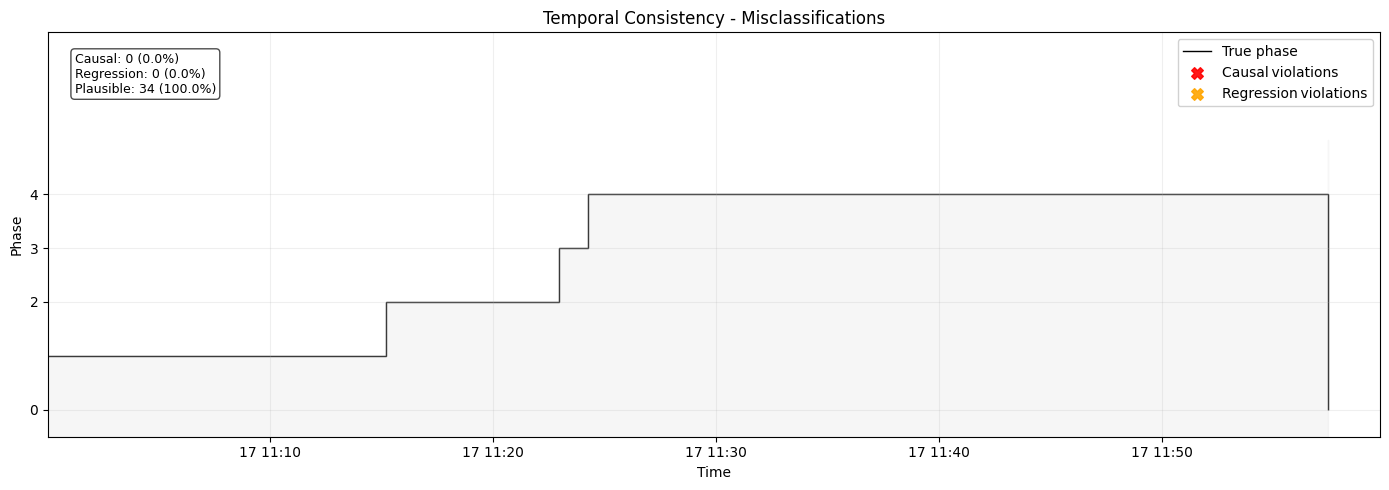

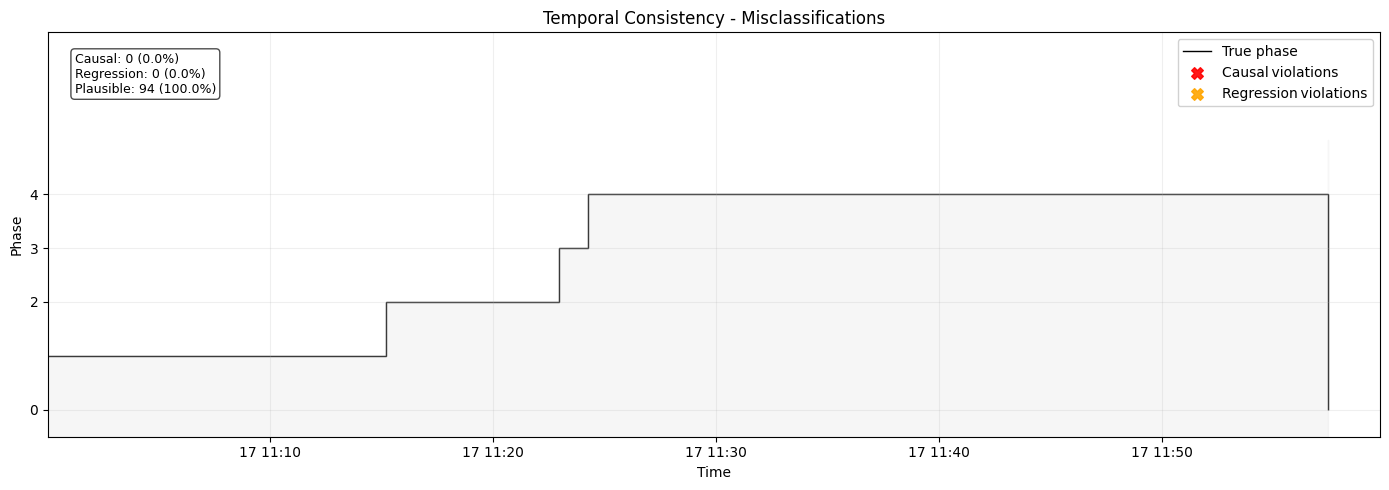

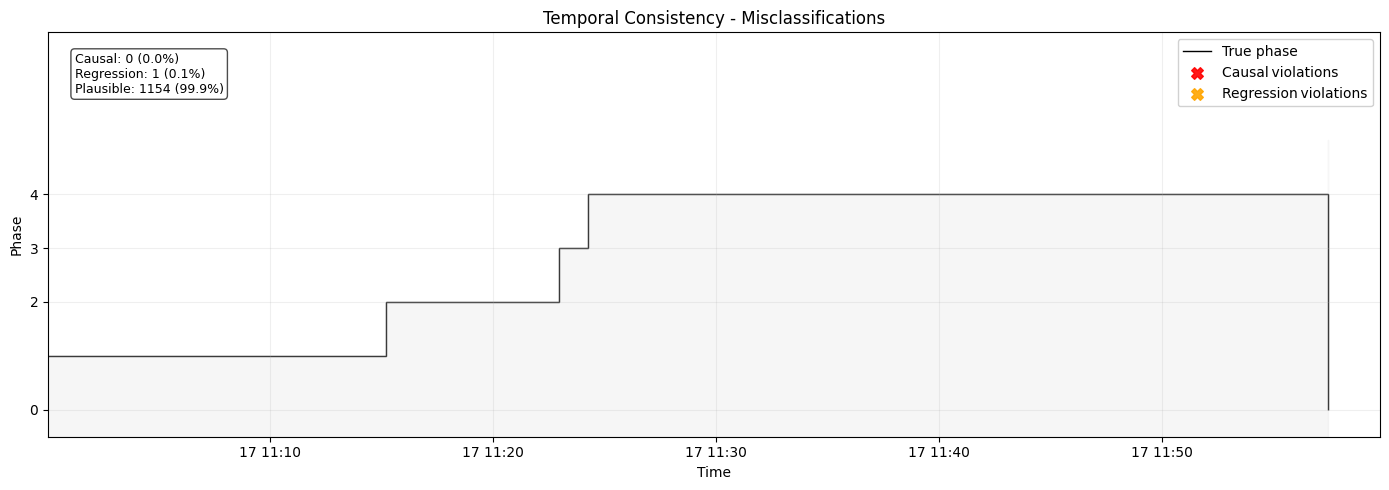

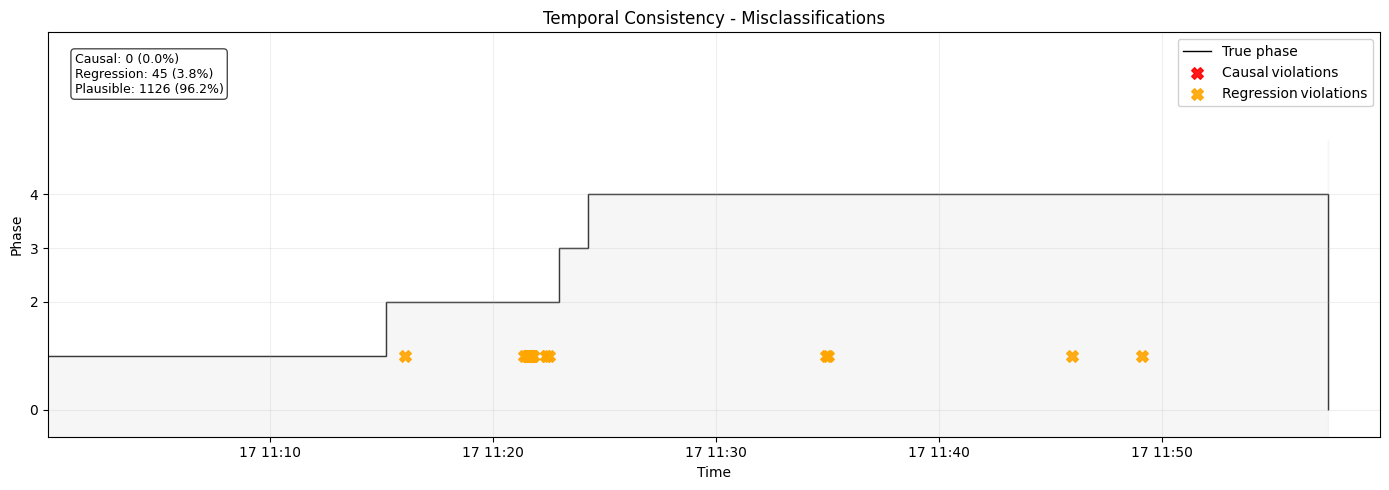

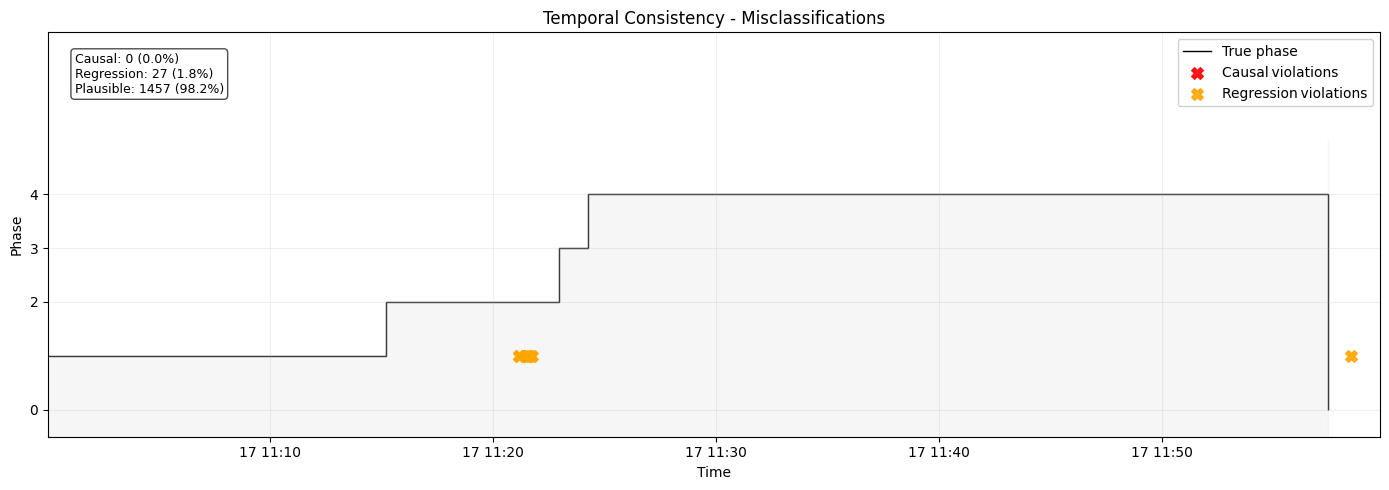

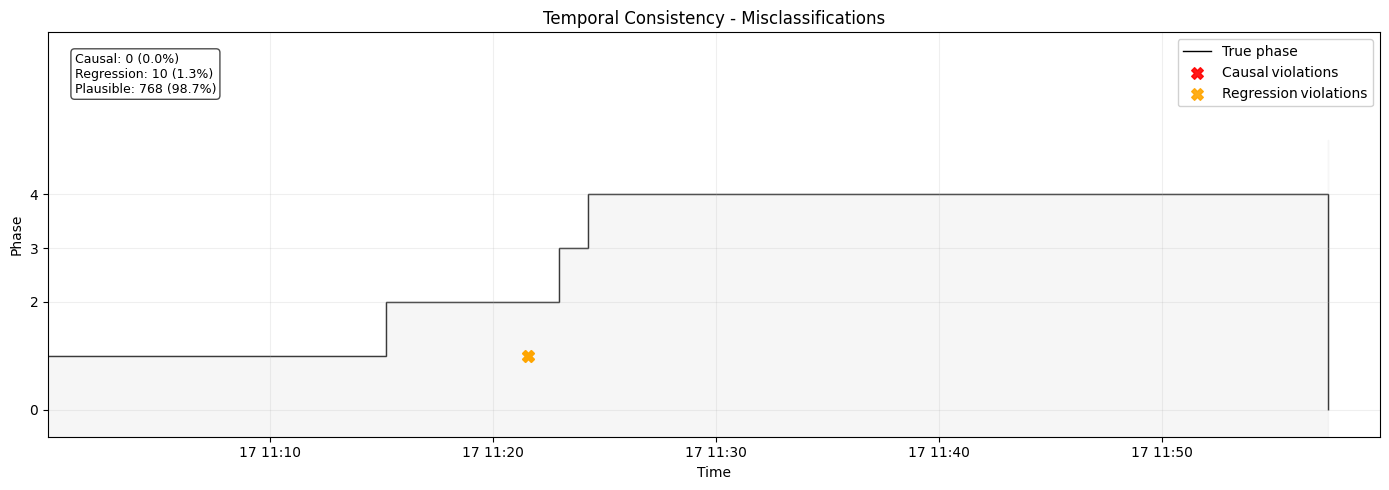

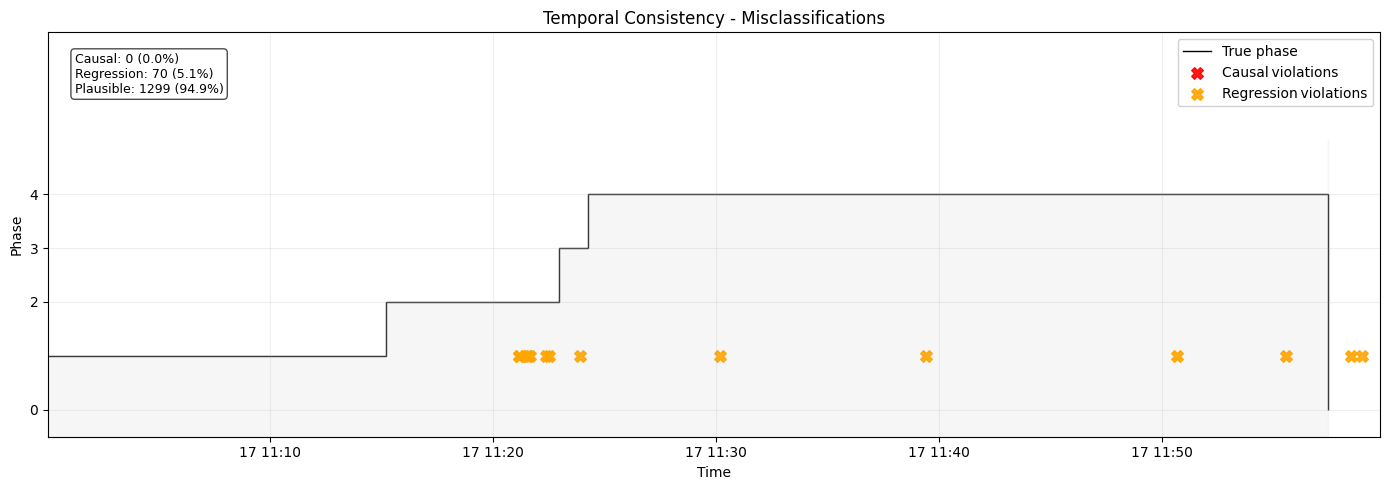

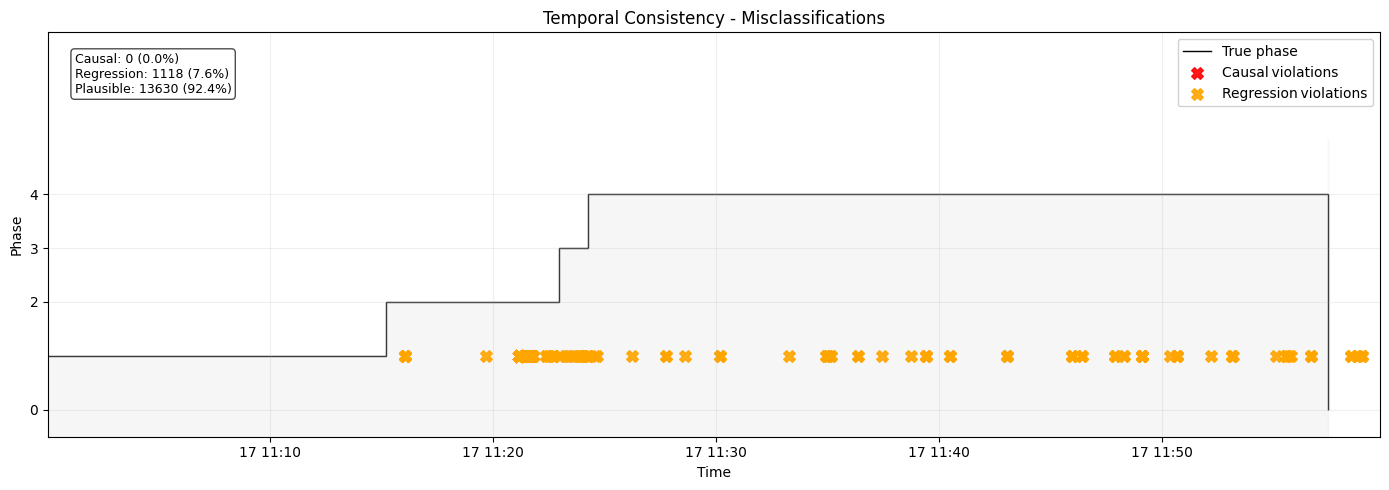

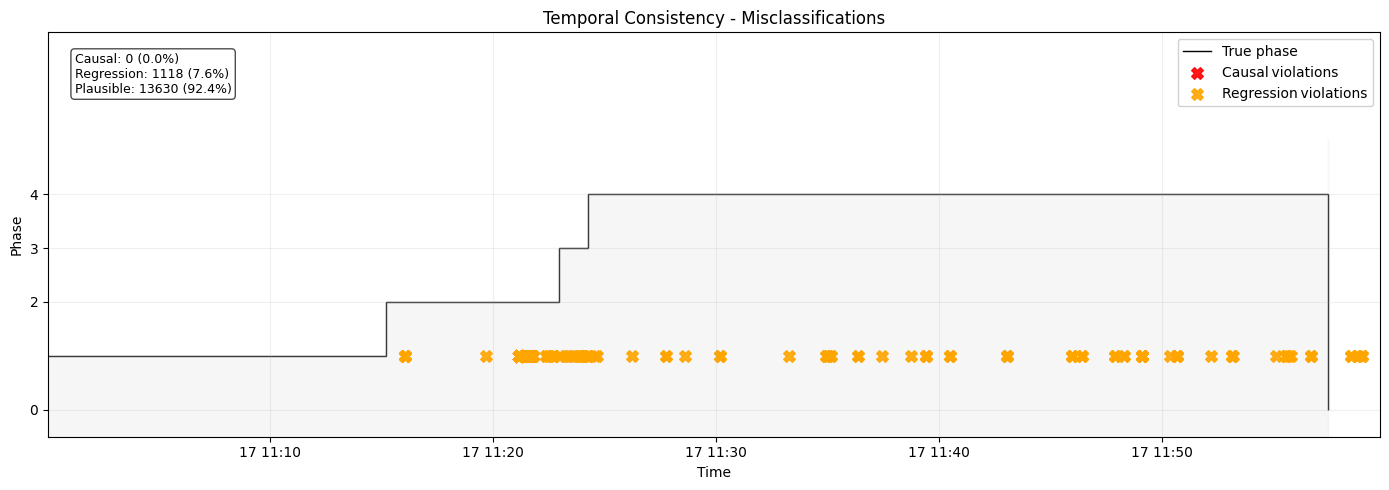

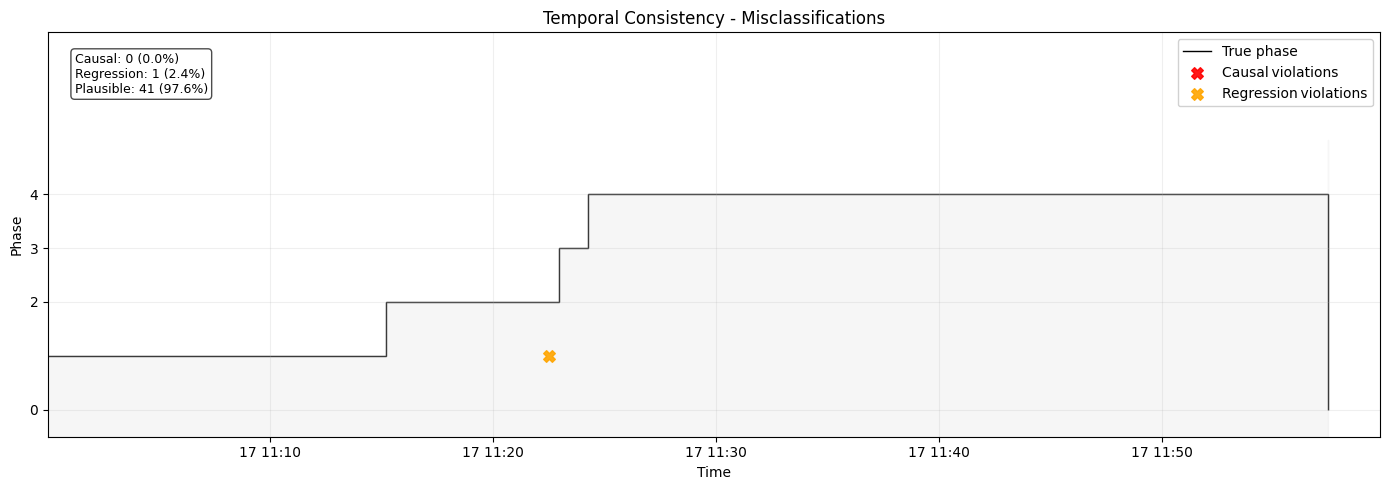

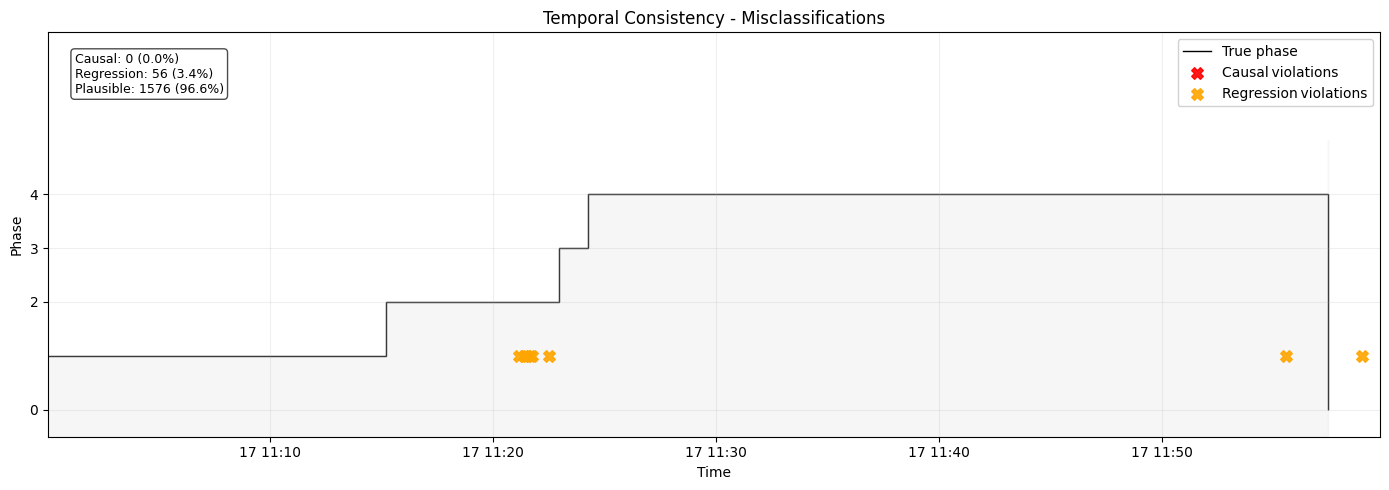

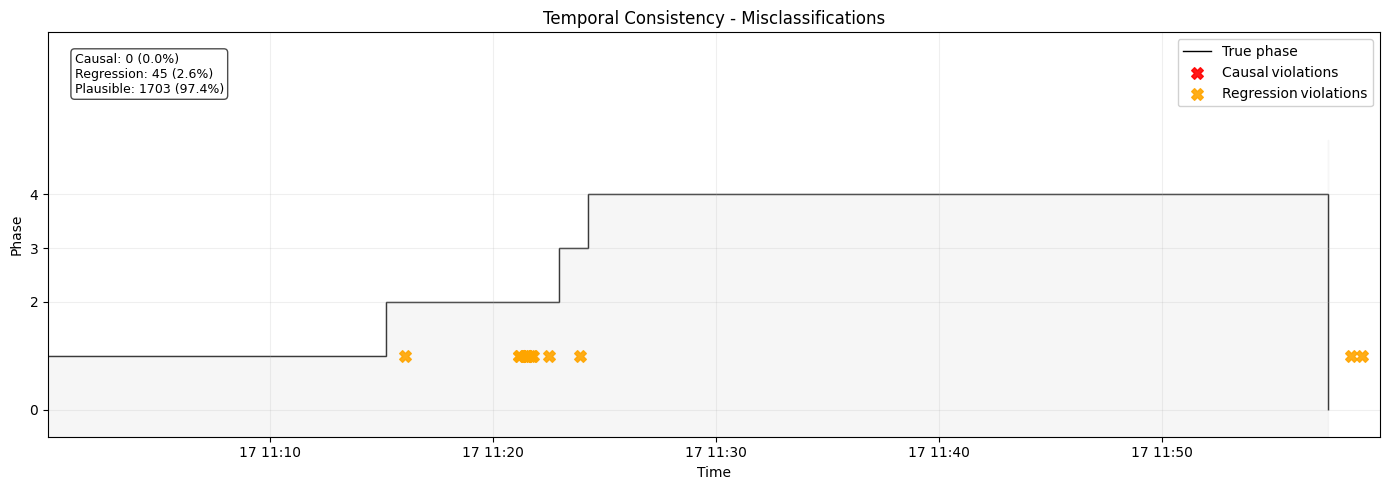

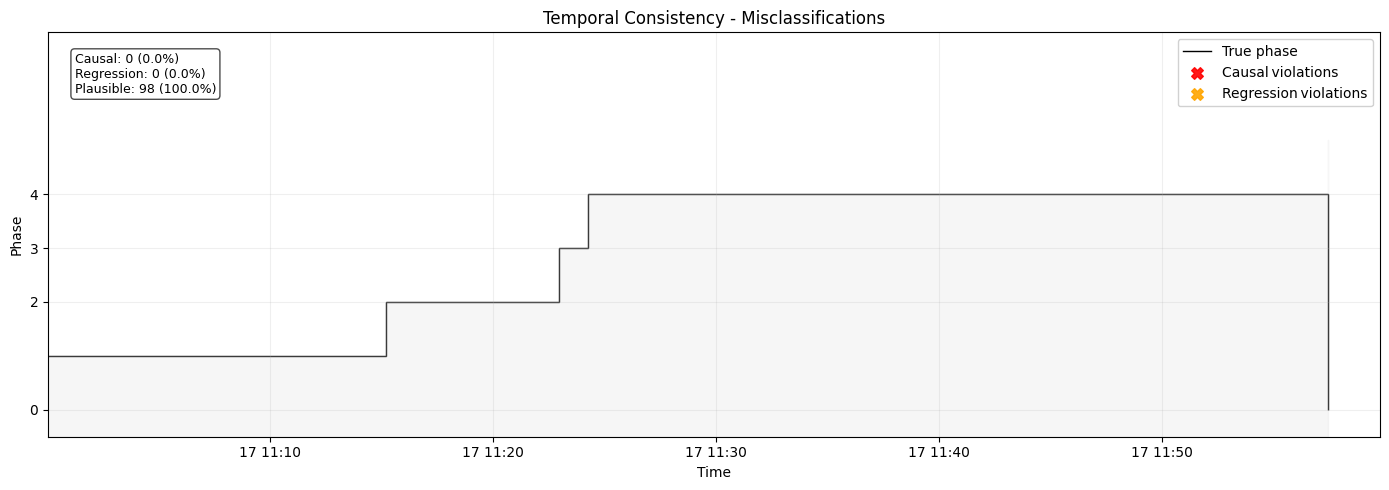

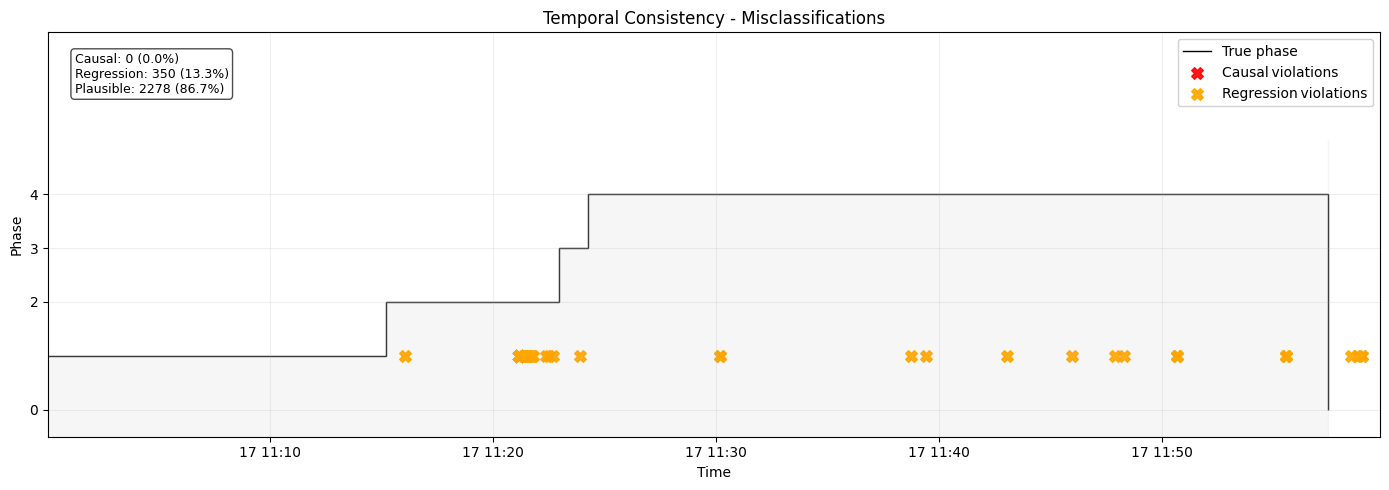

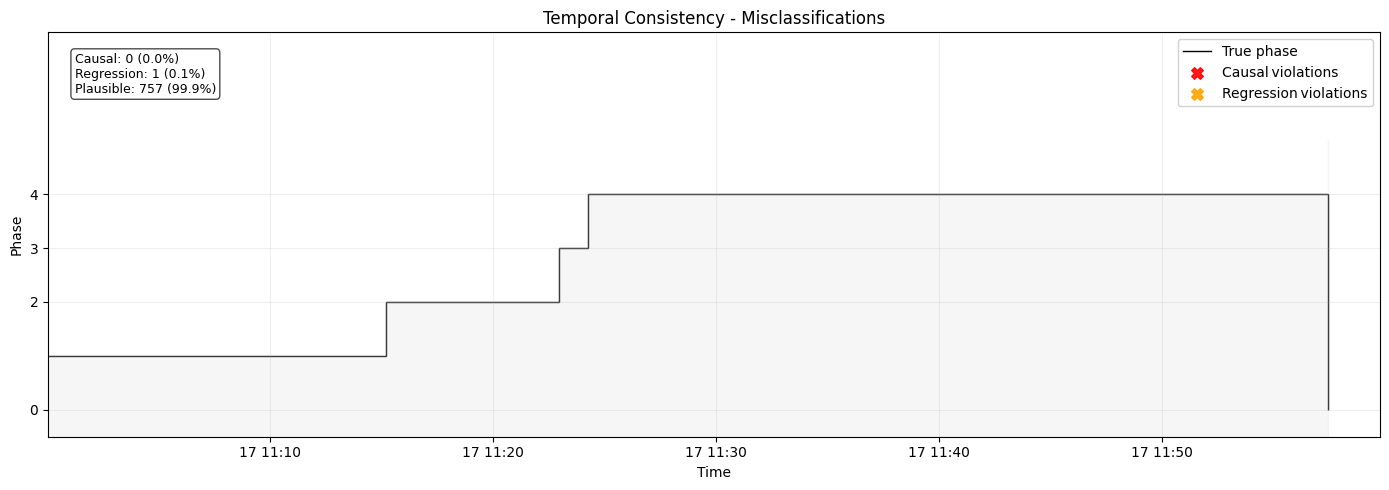

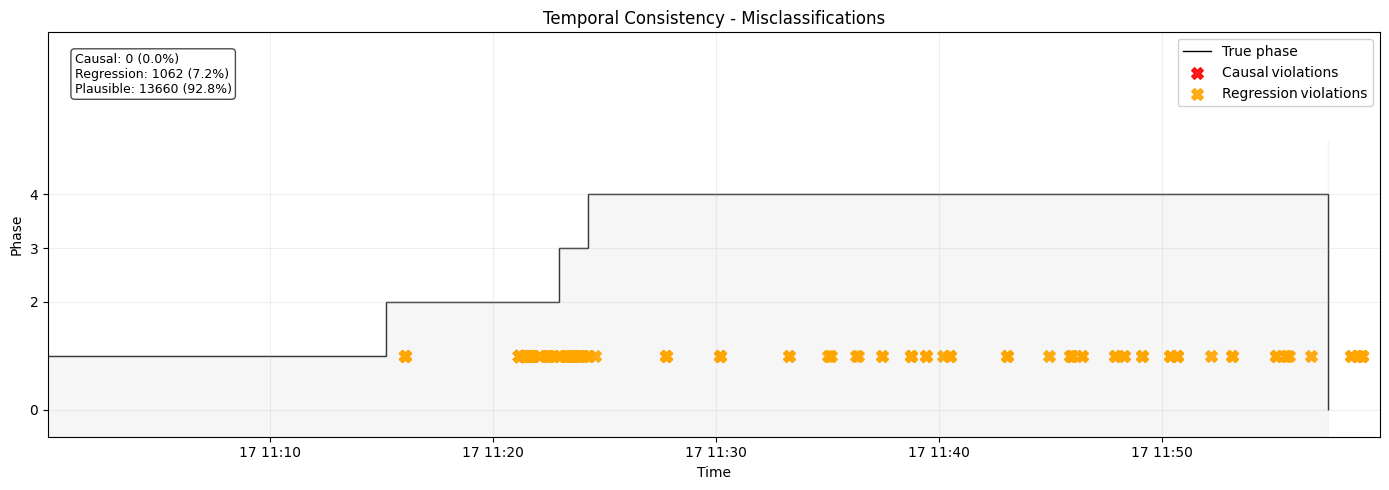

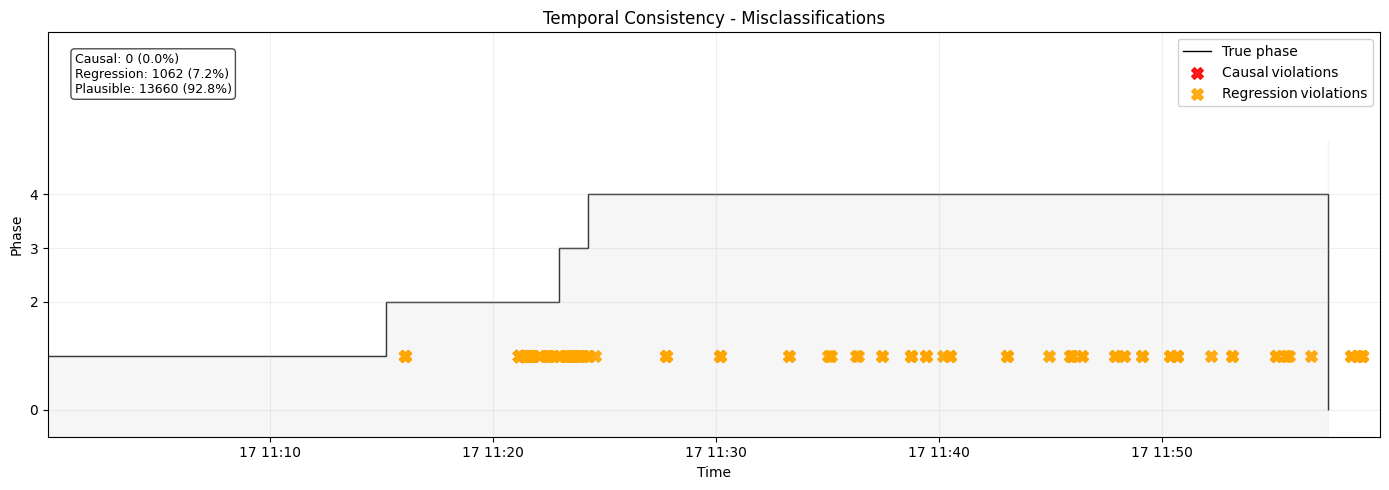

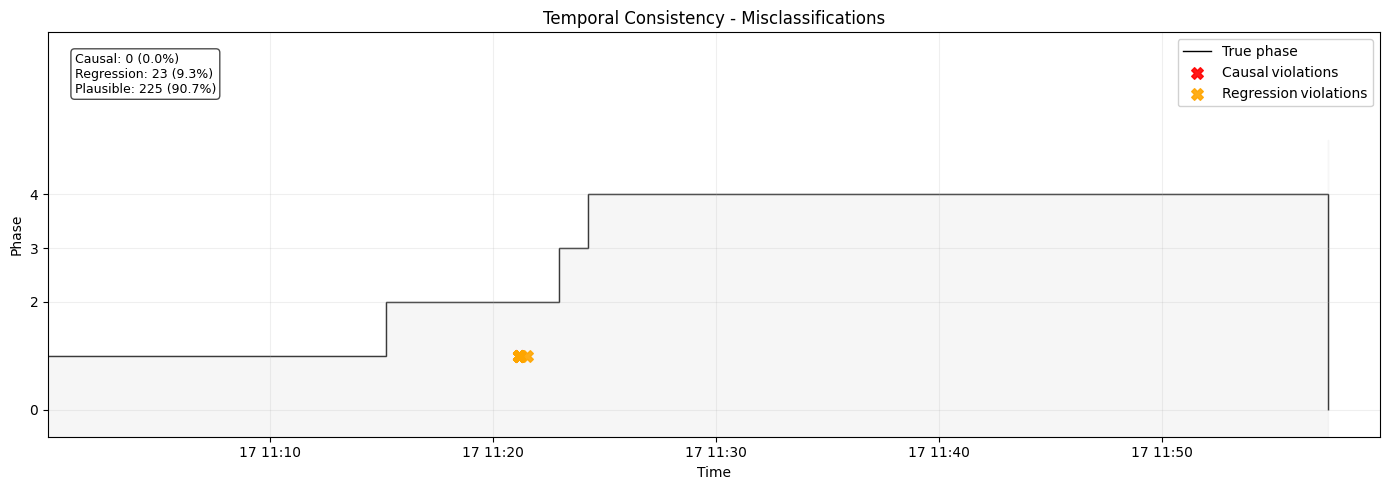

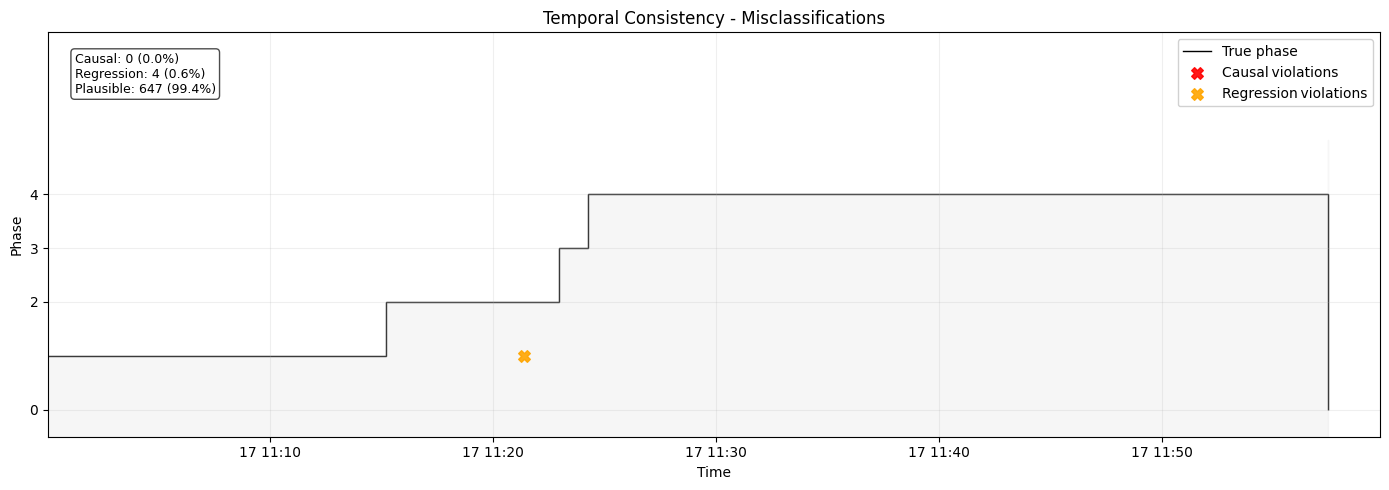

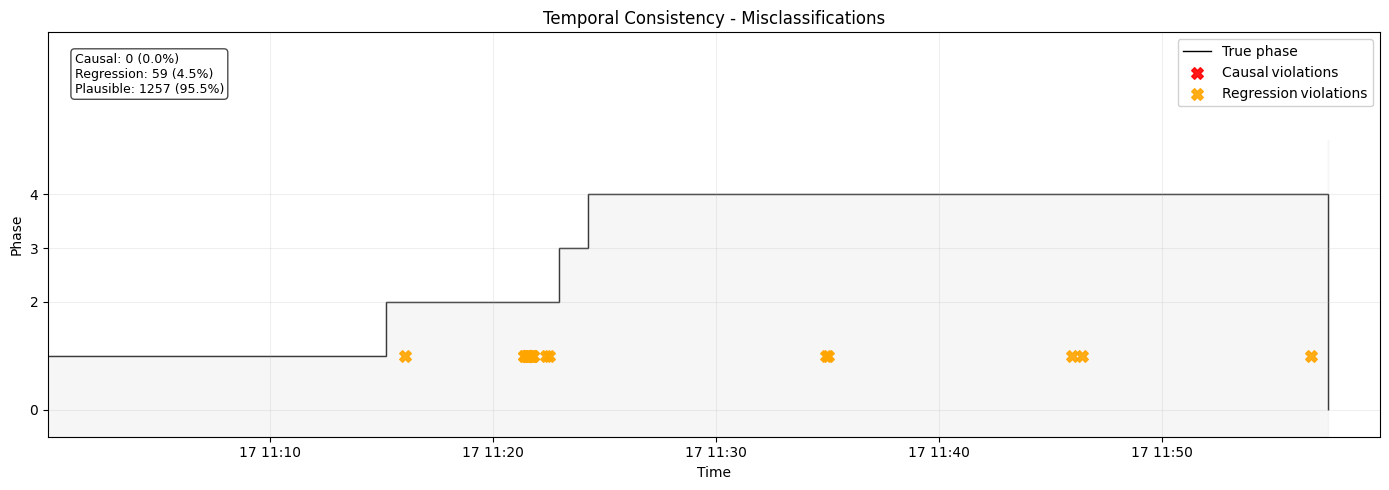

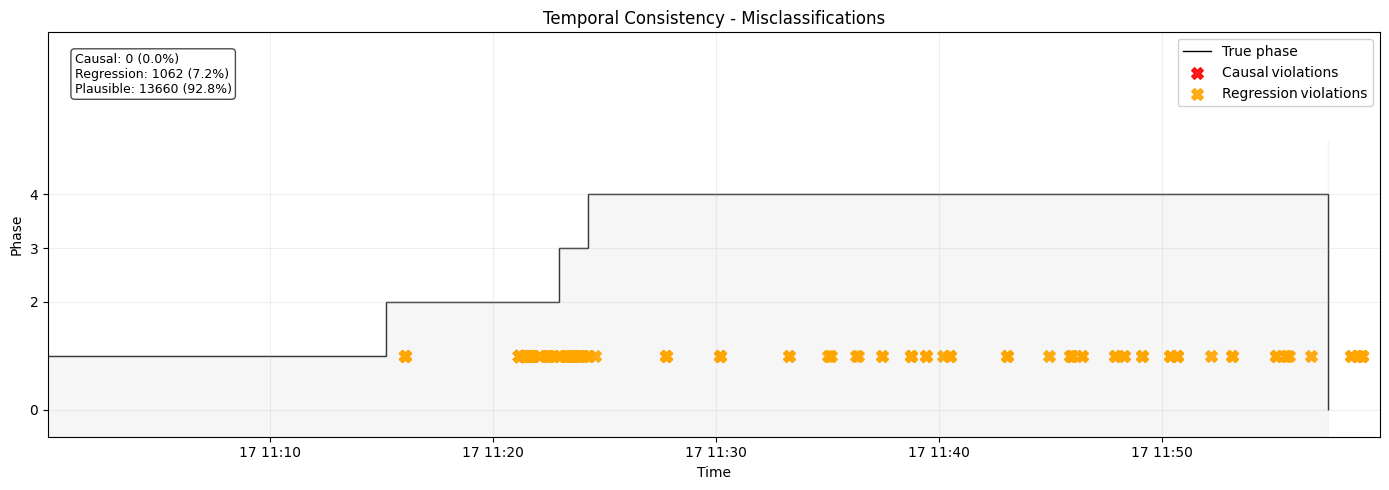

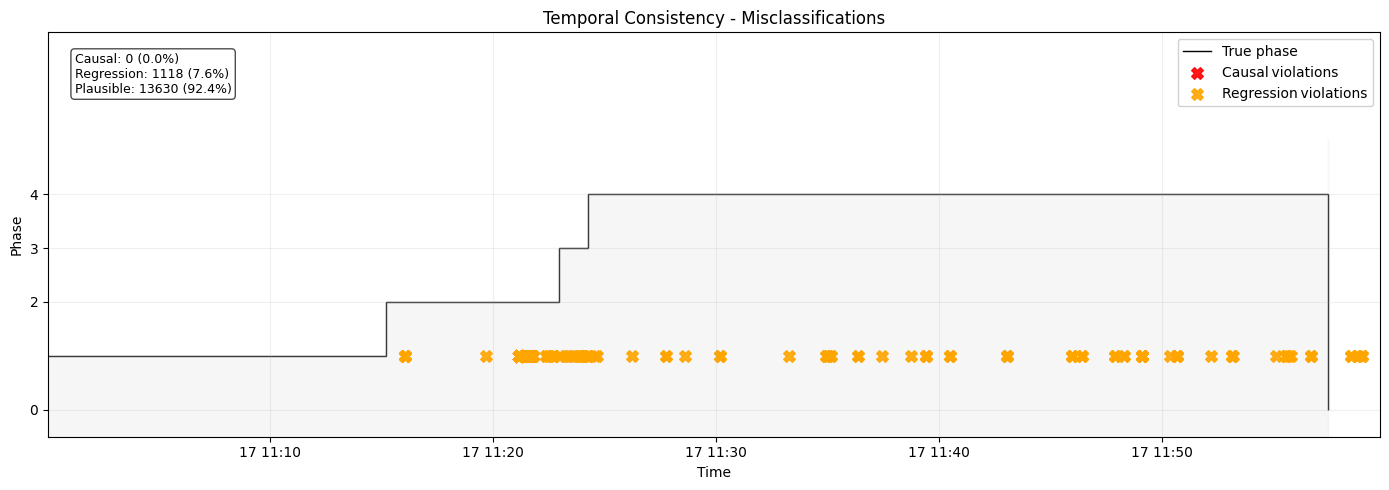

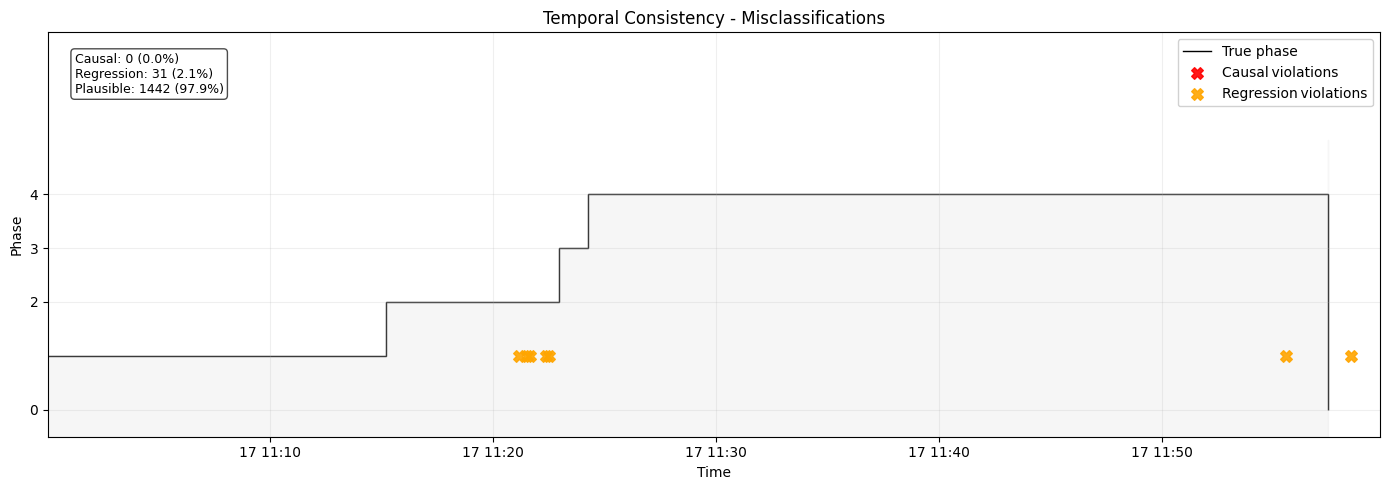

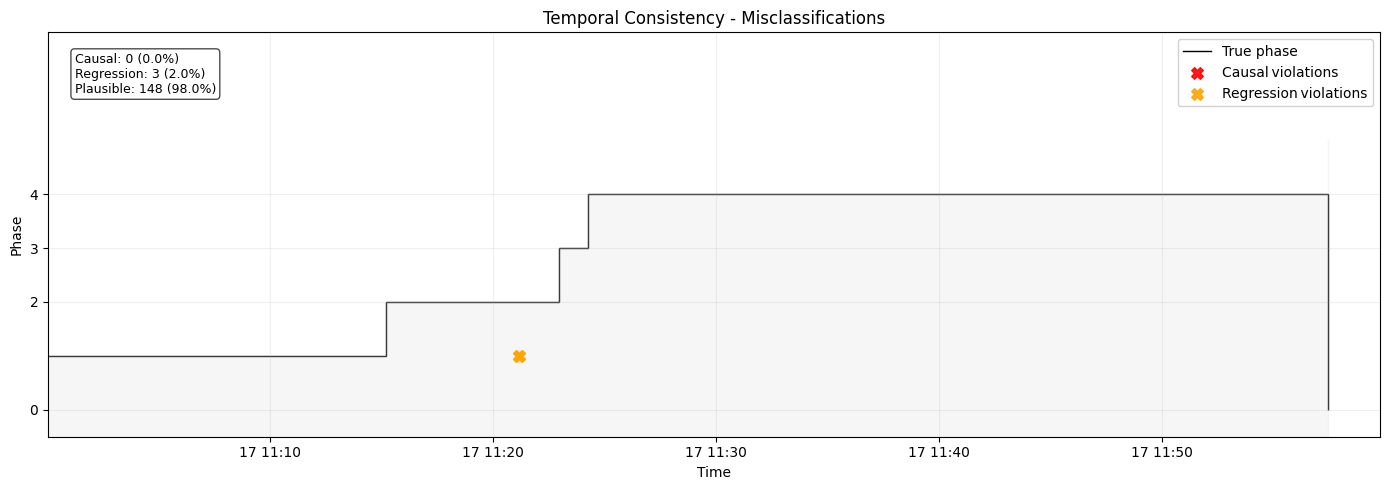

In [64]:
err_folder = Path(f"../../experiments/{dataset}/{experiment}/deepproblog/errors")
file_paths = list(err_folder.iterdir())

for file_path in file_paths:
    experiment_name_full = str(file_path.stem)
    experiment_name = experiment_name_full[:-16] # Remove "run_id"
    parts = experiment_name.split("_")
    
    cache_file_name = f"{logic_file}_{parts[-2]}_{parts[-1]}_test.pkl"
    
    print(f"Processing {experiment_name}")
    
    cache_df = load_dpl_dataset(logic_file, cache_file_name)

    with open(file_path, "r") as f:
        errors = json.load(f)
    
    dpl_to_orig = dict(zip(cache_df['dpl_index'], cache_df['orig_index']))

    original_indices = []
    mis_y_preds = []
    mis_y_trues = []

    for error in errors:
        dpl_index = error['index']
        original_indices.append(dpl_to_orig[dpl_index])

        y_pred = error['predicted']
        y_true = error['actual']
        mis_y_preds.append(phase_map[y_pred])
        mis_y_trues.append(phase_map[y_true])

    misclassified = df.loc[original_indices].copy()
    misclassified['y_pred'] = mis_y_preds
    misclassified['y_true'] = mis_y_trues

    print(f"Experiment: {experiment_name_full}")
    metrics = experiments[experiment_name_full]['metrics']

    f1 = metrics["macro_f1"]
    wrong, causal, regression, plausible, temp_metrics_dict = temp_metrics(misclassified, f1, phase_starts)
    
    results.append({
        "model": f"{experiment_name_full}",
        "Macro F1": metrics["macro_f1"],
        "False Positive Rate": metrics["false_alarm_rate"],
        "Detection Rate": metrics["detection_rate"],
        "total_wrong": temp_metrics_dict["total_wrong"],
        "num_causal": temp_metrics_dict["num_causal"],
        "num_regression": temp_metrics_dict["num_regression"],
        # "num_plausible": temp_metrics_dict["num_plausible"],
        "causal_rate": temp_metrics_dict["causal_rate"],
        "regression_rate": temp_metrics_dict["regression_rate"],
        # "plausible_rate": temp_metrics_dict["plausible_rate"],
        "temp_score": temp_metrics_dict["temp_score"]
    })

    plot_temp_consistency(
        df, 
        phase_bounds, 
        causal,
        regression,
        plausible,
        temp_metrics_dict,
        exp_name=experiment_name_full, 
        out_dir = plots_dir,
        attack_start=attack_start,
        attack_end=attack_end,
        save_plot=True,
        show_plot=False
    )

### Baseline Models

Processing multiclass_reduced_w10_full...
Saving plot to ../../reports/aitv2/ablation_study/temp_plots/multiclass_reduced_w10_full.png...
Processing multiclass_reduced_w10_balanced...
Saving plot to ../../reports/aitv2/ablation_study/temp_plots/multiclass_reduced_w10_balanced.png...
Processing ensemble_aug_w10_full...
Saving plot to ../../reports/aitv2/ablation_study/temp_plots/ensemble_aug_w10_full.png...
Processing multiclass_reduced_w100_full...
Saving plot to ../../reports/aitv2/ablation_study/temp_plots/multiclass_reduced_w100_full.png...
Processing multiclass_full_w100_balanced...
Saving plot to ../../reports/aitv2/ablation_study/temp_plots/multiclass_full_w100_balanced.png...
Processing multiclass_reduced_w100_balanced...
Saving plot to ../../reports/aitv2/ablation_study/temp_plots/multiclass_reduced_w100_balanced.png...
Processing ensemble_aug_w10_balanced...
Saving plot to ../../reports/aitv2/ablation_study/temp_plots/ensemble_aug_w10_balanced.png...
Processing ensemble_full_w

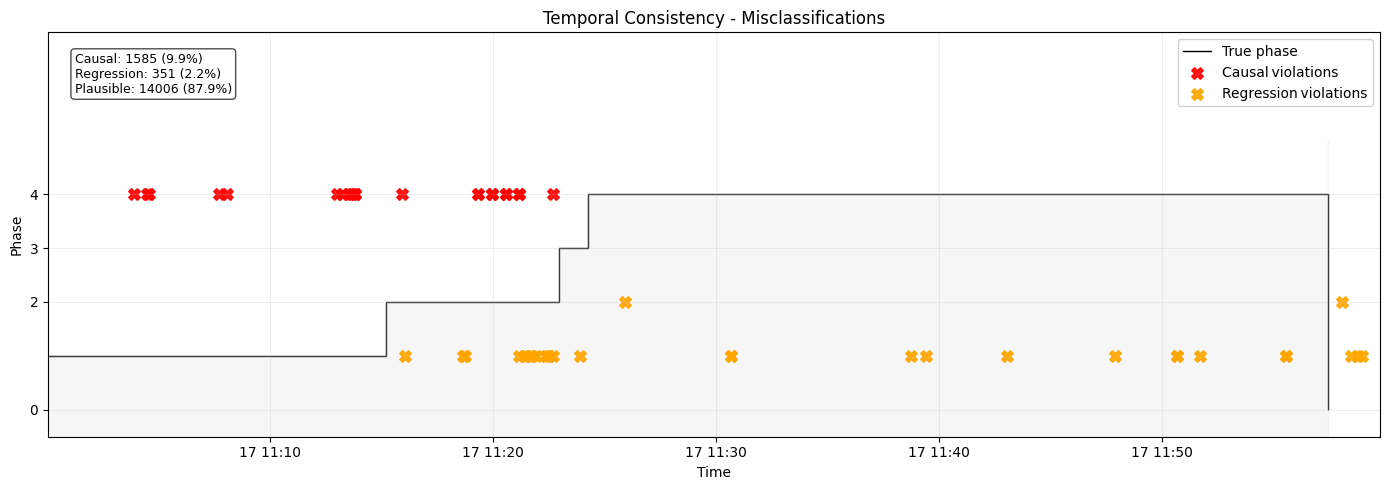

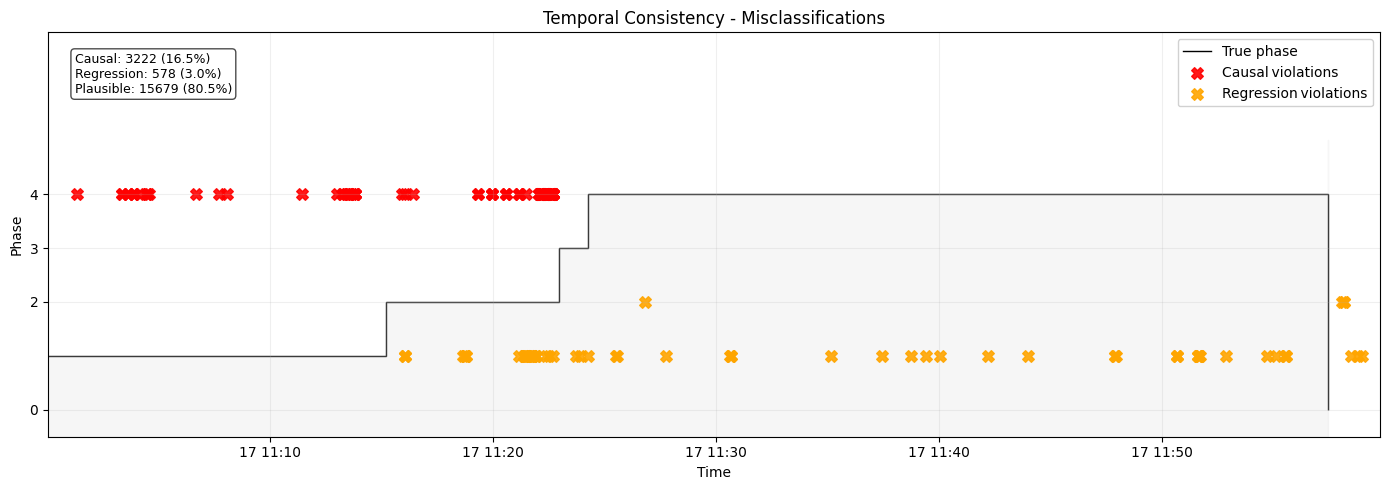

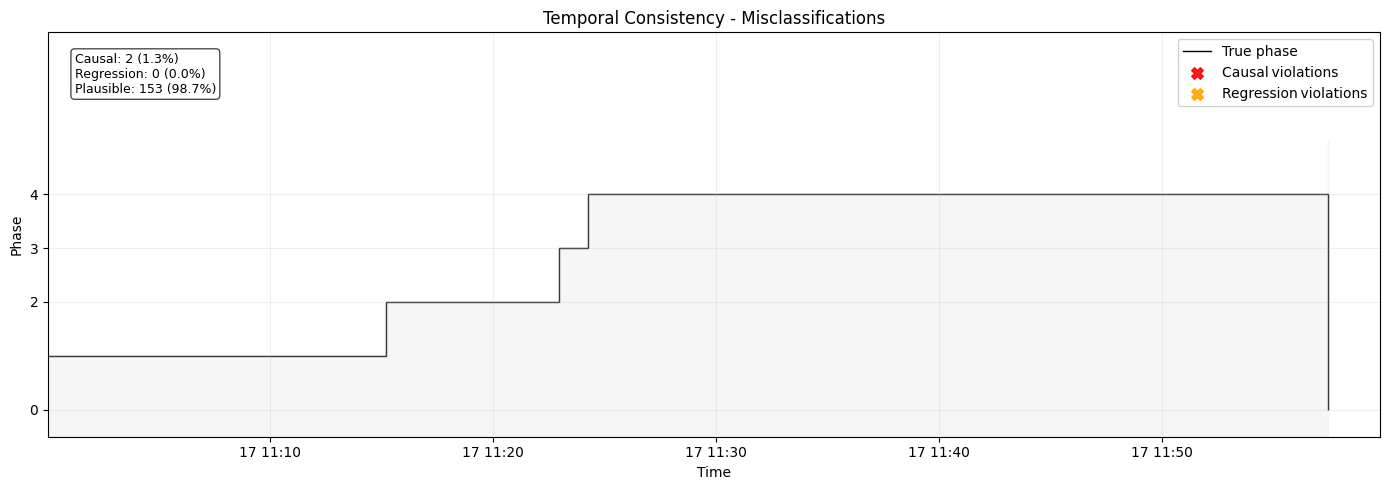

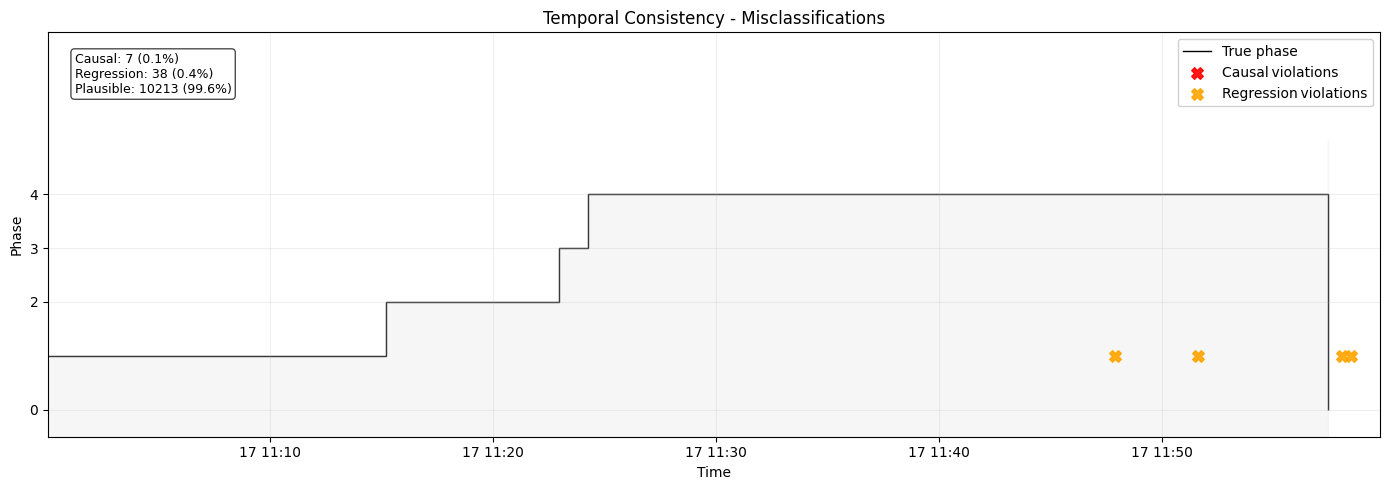

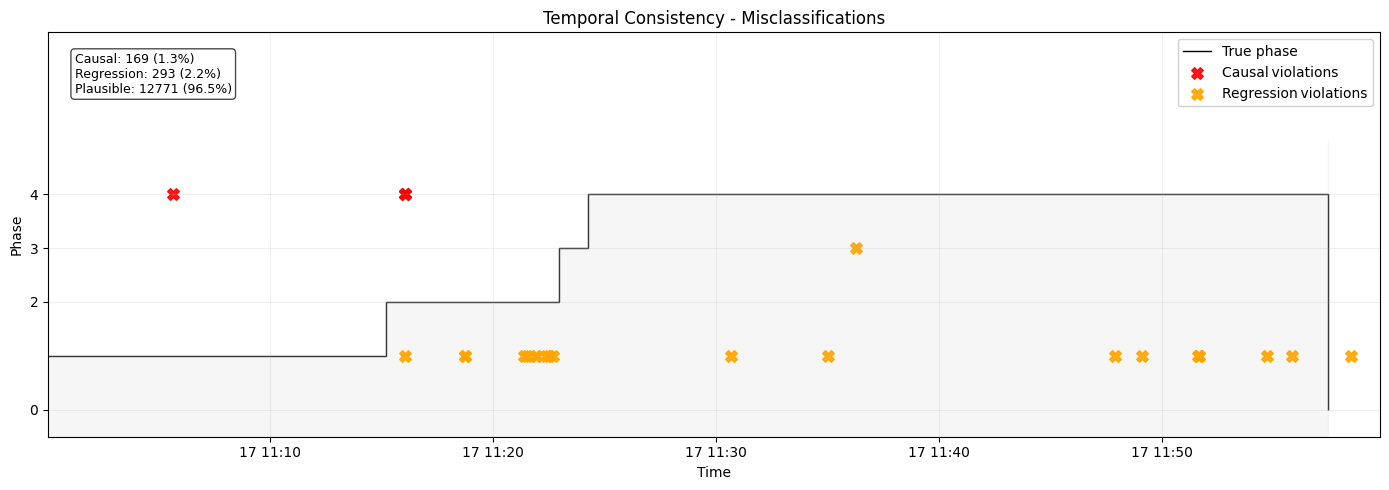

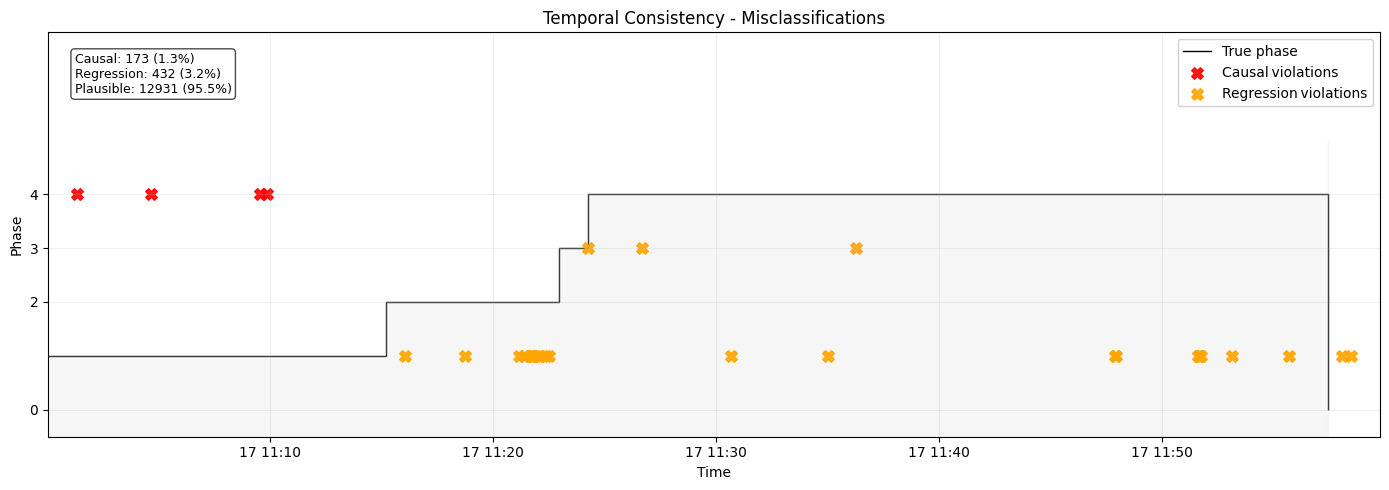

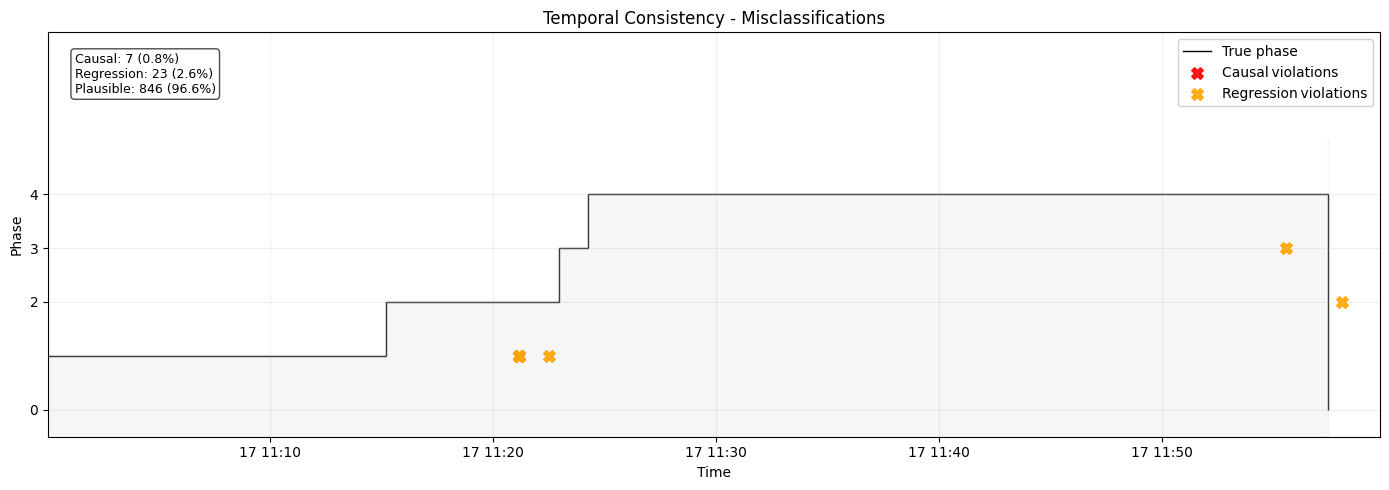

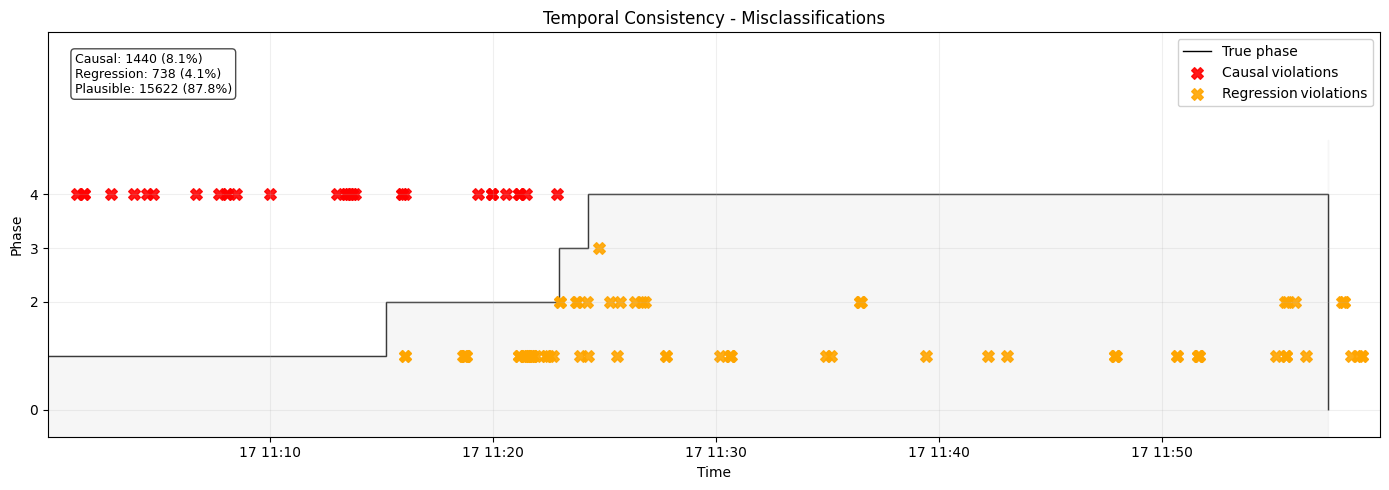

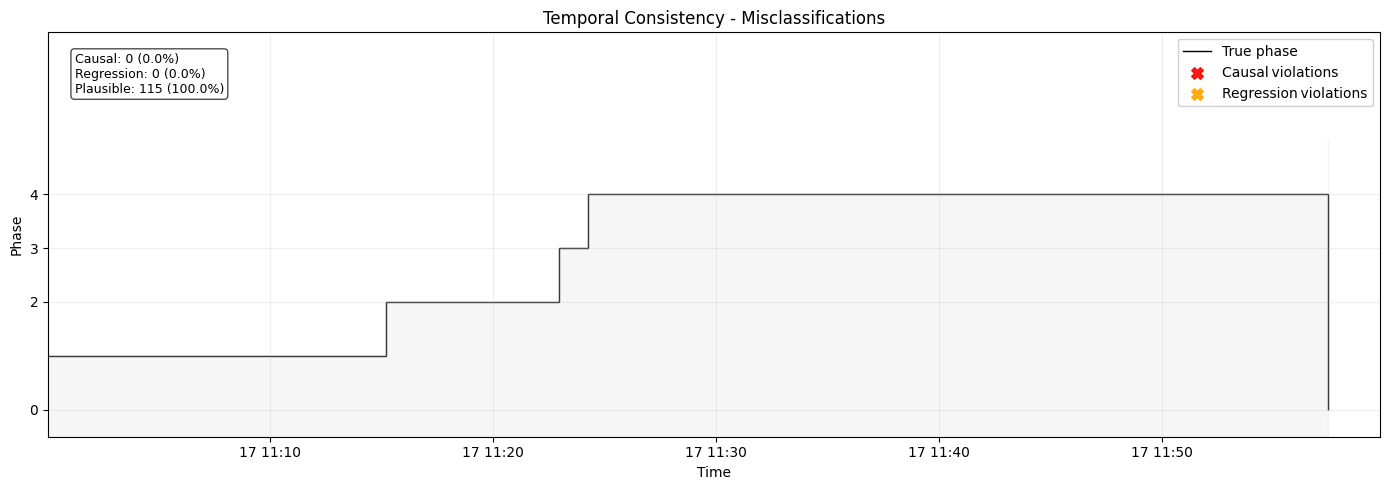

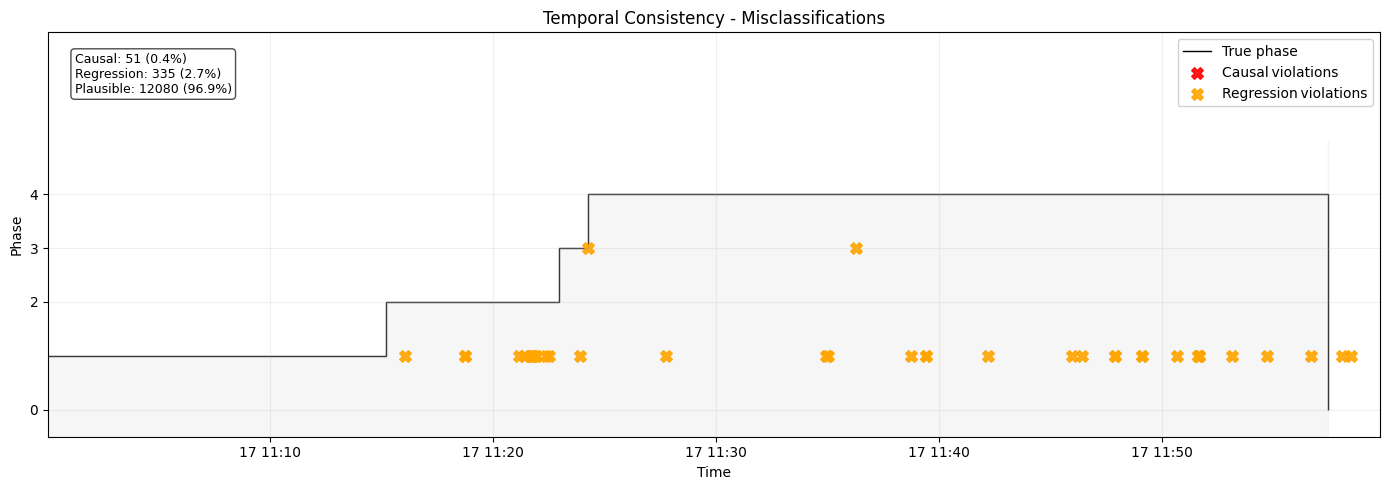

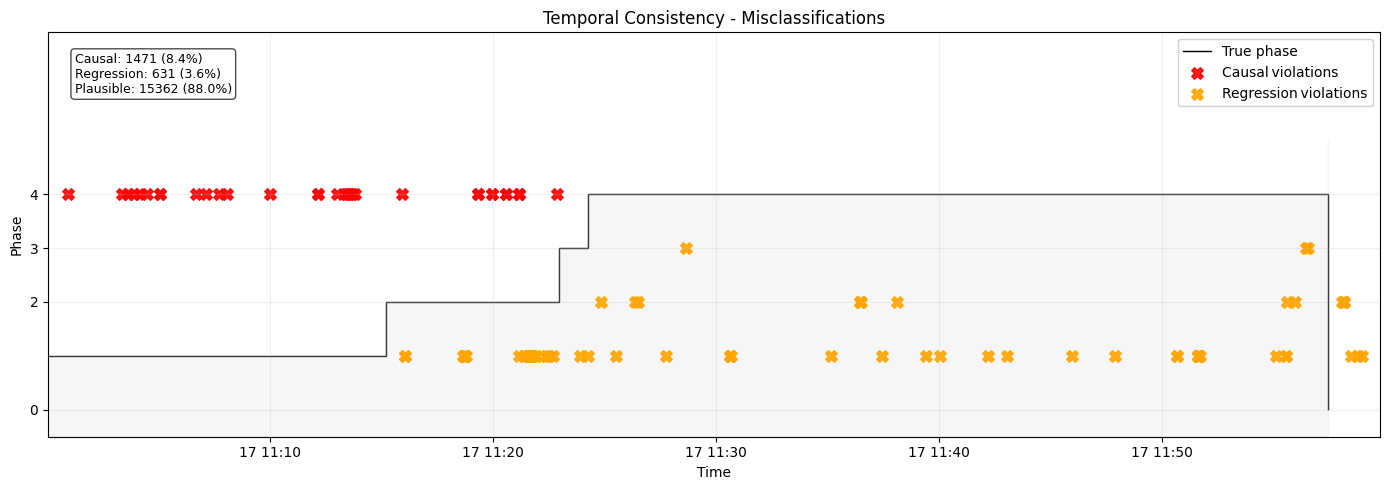

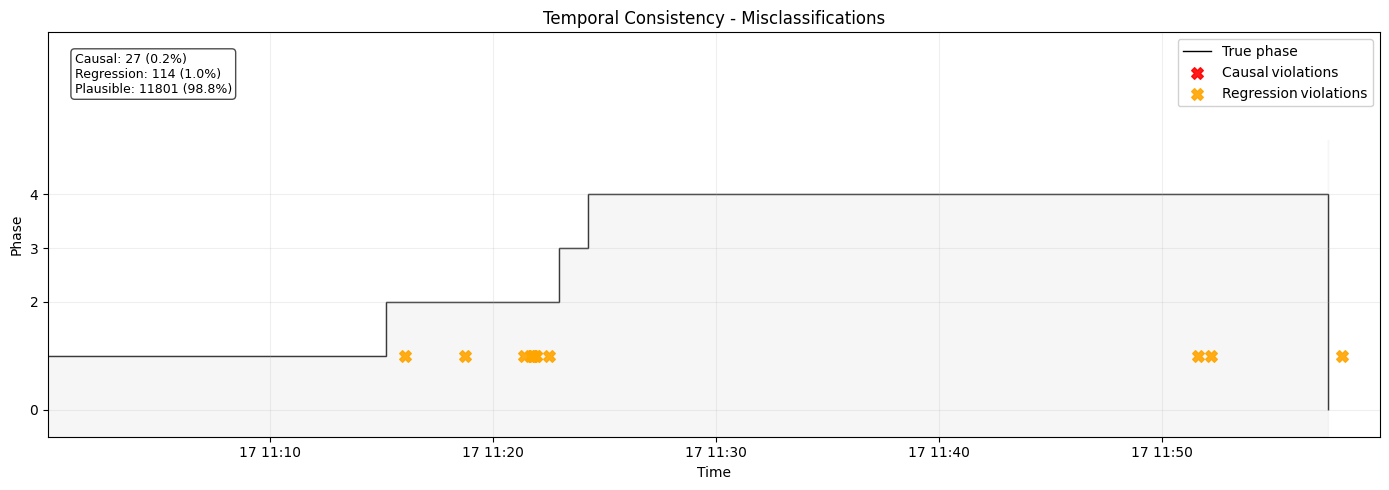

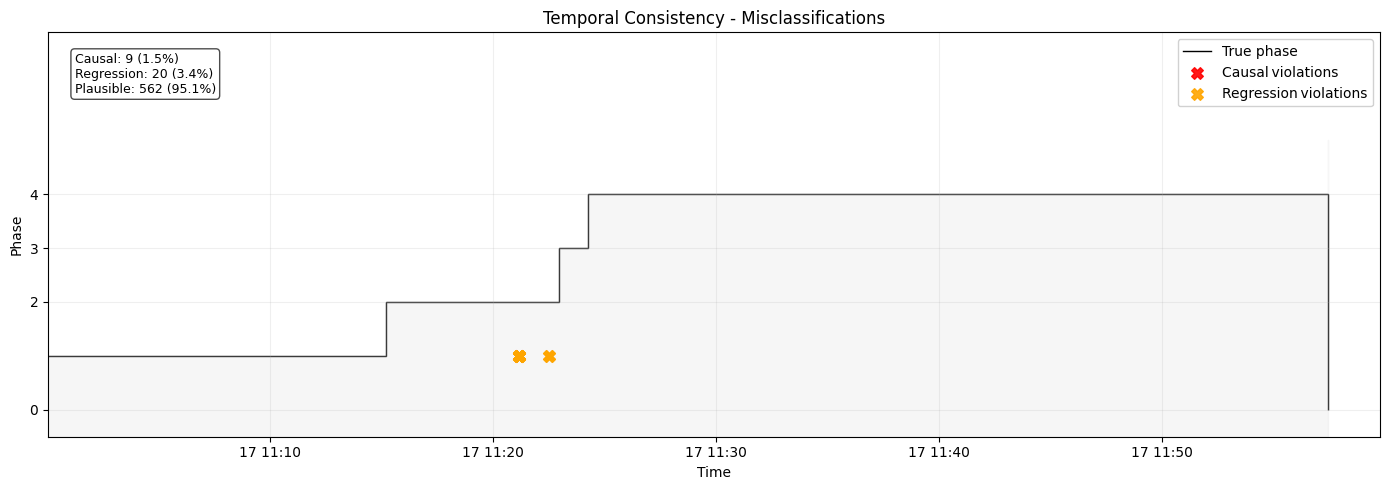

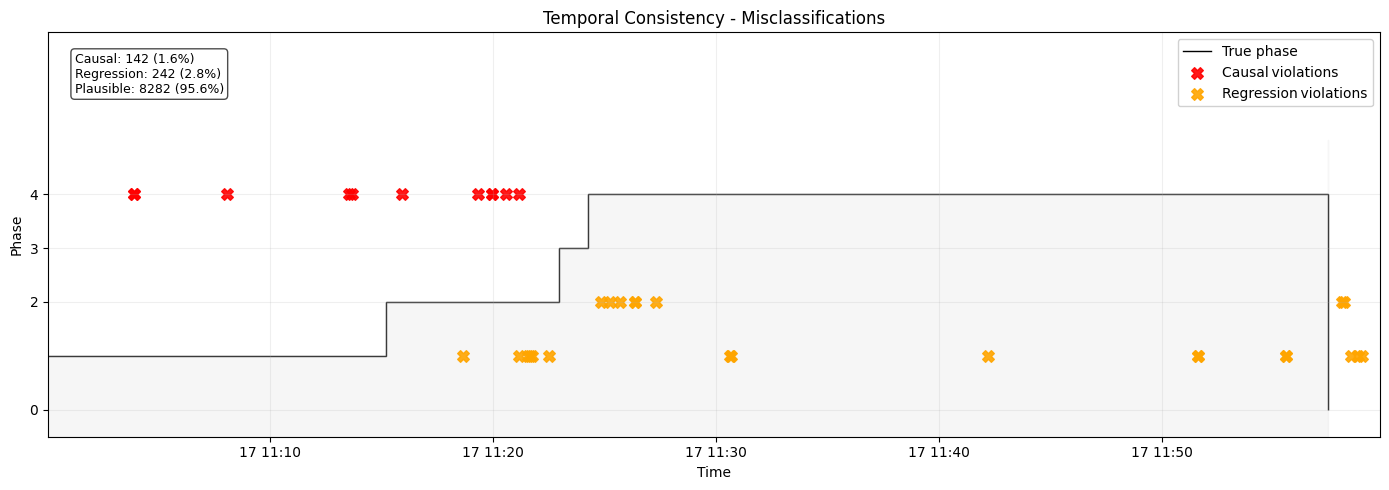

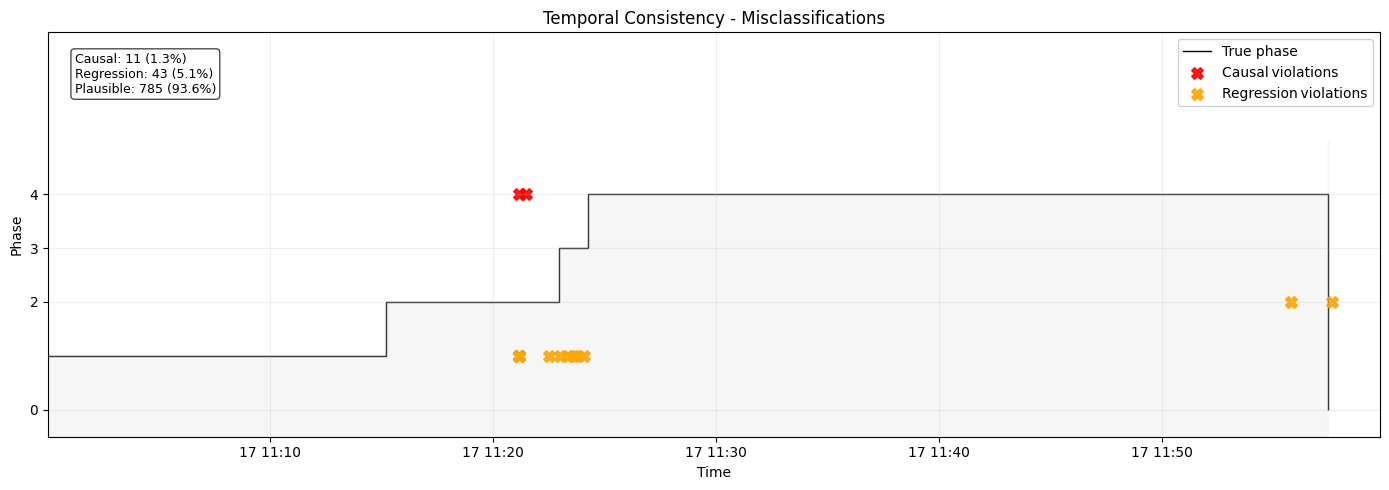

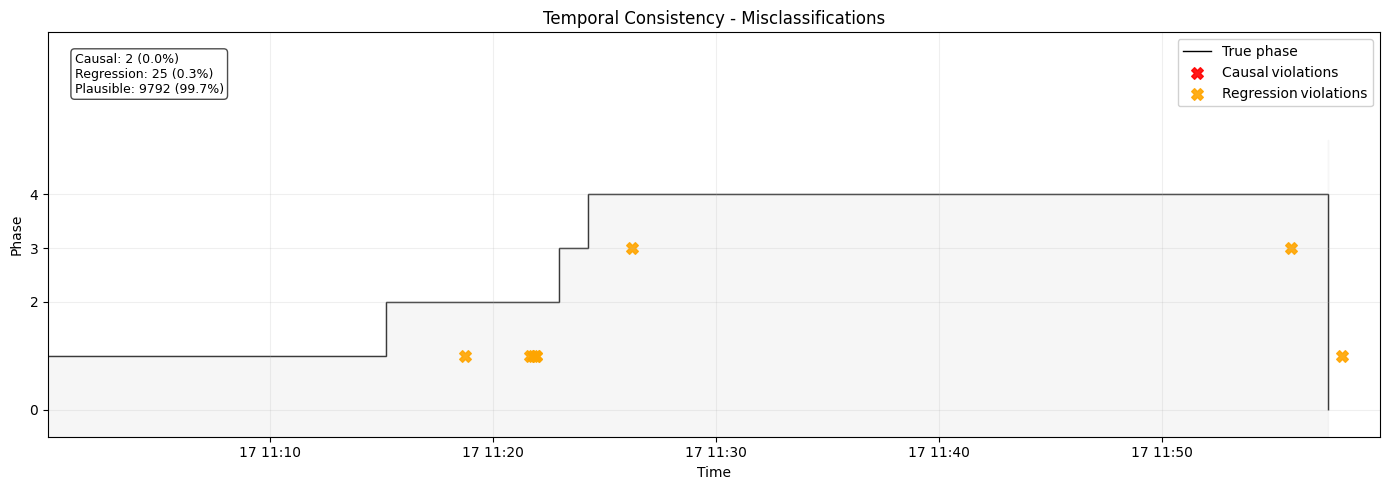

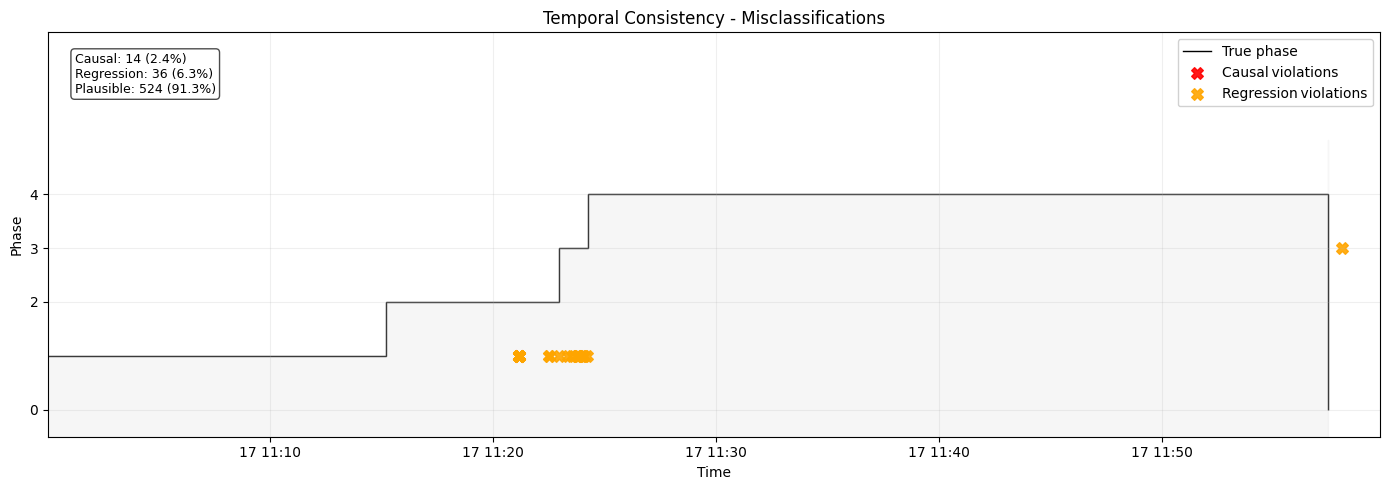

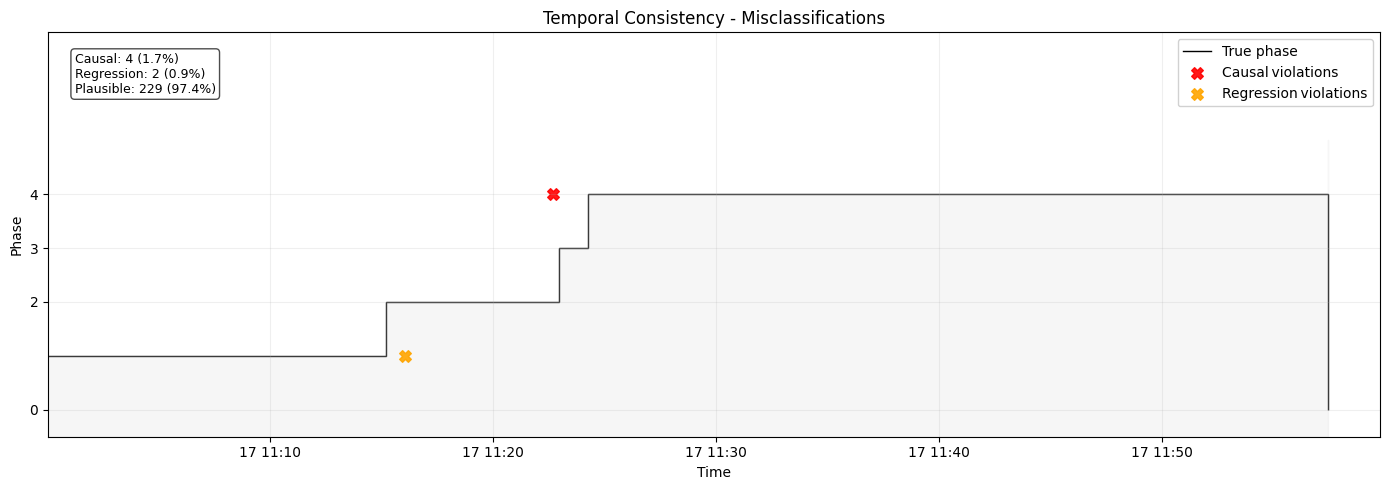

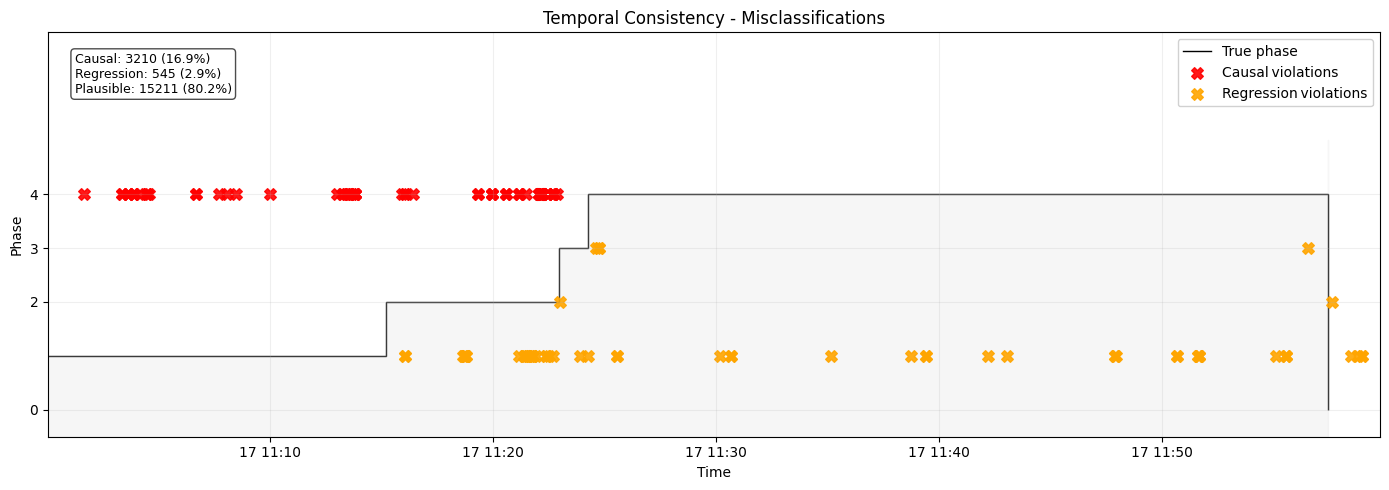

In [65]:
metrics_dir = Path(f"../../experiments/{dataset}/{experiment}/baselines/metrics")
file_paths = list(metrics_dir.iterdir())

for file_path in file_paths:

    with open(file_path) as f:
        metrics = json.load(f)

    experiment_name = file_path.stem

    if "multiclass" in experiment_name:
        model = "multiclass"
    elif "ensemble" in experiment_name:
        model = "ensemble"

    print(f"Processing {experiment_name}...")

    # --- Load misclassification info ---
    real_flow_indices = metrics["real_flow_indices"]
    misclassified = df.iloc[real_flow_indices].copy()
    misclassified["y_true"] = metrics["y_true"]
    misclassified["y_pred"] = metrics["y_pred"]

    # --- Compute violation categories ---
    f1 = metrics["Macro F1"]
    wrong, causal, regression, plausible, temp_metrics_dict = temp_metrics(misclassified, f1, phase_starts)

    # --- Collect everything ---
    results.append({
        "model": f"{experiment_name}",
        "Macro F1": metrics["Macro F1"],
        "False Positive Rate": metrics["False Alarm Rate"],
        "Detection Rate": metrics["Detection Rate"],
        "total_wrong": temp_metrics_dict["total_wrong"],
        "num_causal": temp_metrics_dict["num_causal"],
        "num_regression": temp_metrics_dict["num_regression"],
        # "num_plausible": temp_metrics_dict["num_plausible"],
        "causal_rate": temp_metrics_dict["causal_rate"],
        "regression_rate": temp_metrics_dict["regression_rate"],
        # "plausible_rate": temp_metrics_dict["plausible_rate"],
        "temp_score": temp_metrics_dict["temp_score"]
    })

    # Create plots
    plot_temp_consistency(
        df, 
        phase_bounds, 
        causal,
        regression,
        plausible,
        temp_metrics_dict,
        exp_name=experiment_name, 
        out_dir = plots_dir,
        attack_start=attack_start,
        attack_end=attack_end,
        save_plot=True,
        show_plot=False
    )

In [66]:
results_df = pd.DataFrame(results)
results_df

,model,Macro F1,False Positive Rate,Detection Rate,total_wrong,num_causal,num_regression,causal_rate,regression_rate,temp_score
0,ait_logic_pretrained_aug_w100_full_20260507_18...,0.955833,0.000075,0.996804,34,0,0,0.000000,0.000000,0.955833
1,ait_logic_pretrained_aug_w10_balanced_20260509...,0.871627,0.000337,0.993479,94,0,0,0.000000,0.000000,0.871627
2,ait_logic_pretrained_reduced_w100_full_2026050...,0.885248,0.002097,0.883489,1155,0,1,0.000000,0.000866,0.885075
3,ait_logic_scratch_full_w100_full_20260512_232223,0.569013,0.001775,0.875632,1171,0,45,0.000000,0.038429,0.561327
4,ait_logic_scratch_full_w10_full_20260513_013858,0.555694,0.001565,0.830317,1484,0,27,0.000000,0.018194,0.552056
5,ait_logic_pretrained_reduced_w100_balanced_202...,0.923346,0.003444,0.957656,778,0,10,0.000000,0.012853,0.920775
6,ait_logic_pretrained_full_w10_balanced_2026050...,0.739277,0.005016,0.906974,1369,0,70,0.000000,0.051132,0.729051
7,ait_logic_scratch_reduced_w100_balanced_202605...,0.699529,0.110423,0.999867,14748,0,1118,0.000000,0.075807,0.684367
8,ait_logic_scratch_aug_w100_balanced_20260505_1...,0.699529,0.110423,0.999867,14748,0,1118,0.000000,0.075807,0.684367
9,ait_logic_pretrained_aug_w100_balanced_2026050...,0.946169,0.000232,0.998535,42,0,1,0.000000,0.023810,0.941407


In [68]:
results_df_sorted_f1 = results_df.sort_values("Macro F1", ascending=False)

# Save metrics to file
results_df_sorted_f1.to_csv(
    reports_dir / "metrics.csv",
    index=False
)

In [71]:
results_df_sorted_f1.head(20)

,model,Macro F1,False Positive Rate,Detection Rate,total_wrong,num_causal,num_regression,causal_rate,regression_rate,temp_score
0,ait_logic_pretrained_aug_w100_full_20260507_18...,0.955833,0.000075,0.996804,34,0,0,0.000000,0.000000,0.955833
9,ait_logic_pretrained_aug_w100_balanced_2026050...,0.946169,0.000232,0.998535,42,0,1,0.000000,0.023810,0.941407
32,multiclass_aug_w100_full,0.930480,0.000756,0.998136,115,0,0,0.000000,0.000000,0.930480
5,ait_logic_pretrained_reduced_w100_balanced_202...,0.923346,0.003444,0.957656,778,0,10,0.000000,0.012853,0.920775
18,ait_logic_pretrained_full_w100_balanced_202605...,0.899308,0.002666,0.960719,651,0,4,0.000000,0.006144,0.898079
2,ait_logic_pretrained_reduced_w100_full_2026050...,0.885248,0.002097,0.883489,1155,0,1,0.000000,0.000866,0.885075
23,ait_logic_scratch_aug_w100_full_20260513_061310,0.872506,0.000457,0.988016,151,0,3,0.000000,0.019868,0.868532
1,ait_logic_pretrained_aug_w10_balanced_20260509...,0.871627,0.000337,0.993479,94,0,0,0.000000,0.000000,0.871627
17,ait_logic_scratch_aug_w10_full_20260509_152317,0.870072,0.001280,0.989752,248,0,23,0.000000,0.092742,0.851523
26,ensemble_aug_w10_full,0.822572,0.000689,0.991616,155,2,0,0.012903,0.000000,0.816120


In [70]:
results_df_sorted_temp = results_df.sort_values("temp_score", ascending=False)

results_df_sorted_temp.head(10)

,model,Macro F1,False Positive Rate,Detection Rate,total_wrong,num_causal,num_regression,causal_rate,regression_rate,temp_score
0,ait_logic_pretrained_aug_w100_full_20260507_18...,0.955833,0.000075,0.996804,34,0,0,0.0,0.000000,0.955833
9,ait_logic_pretrained_aug_w100_balanced_2026050...,0.946169,0.000232,0.998535,42,0,1,0.0,0.023810,0.941407
32,multiclass_aug_w100_full,0.930480,0.000756,0.998136,115,0,0,0.0,0.000000,0.930480
5,ait_logic_pretrained_reduced_w100_balanced_202...,0.923346,0.003444,0.957656,778,0,10,0.0,0.012853,0.920775
18,ait_logic_pretrained_full_w100_balanced_202605...,0.899308,0.002666,0.960719,651,0,4,0.0,0.006144,0.898079
2,ait_logic_pretrained_reduced_w100_full_2026050...,0.885248,0.002097,0.883489,1155,0,1,0.0,0.000866,0.885075
1,ait_logic_pretrained_aug_w10_balanced_20260509...,0.871627,0.000337,0.993479,94,0,0,0.0,0.000000,0.871627
23,ait_logic_scratch_aug_w100_full_20260513_061310,0.872506,0.000457,0.988016,151,0,3,0.0,0.019868,0.868532
17,ait_logic_scratch_aug_w10_full_20260509_152317,0.870072,0.001280,0.989752,248,0,23,0.0,0.092742,0.851523
12,ait_logic_pretrained_aug_w10_full_20260509_174650,0.817900,0.000112,0.988954,98,0,0,0.0,0.000000,0.817900
